In [126]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('dataset/tesla_deliveries_dataset_2015_2025.csv')
df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [128]:
df.duplicated().sum()

0

# EDA

In [129]:
data = df.drop(columns=['Month', 'Source_Type']).copy()

### Distribute

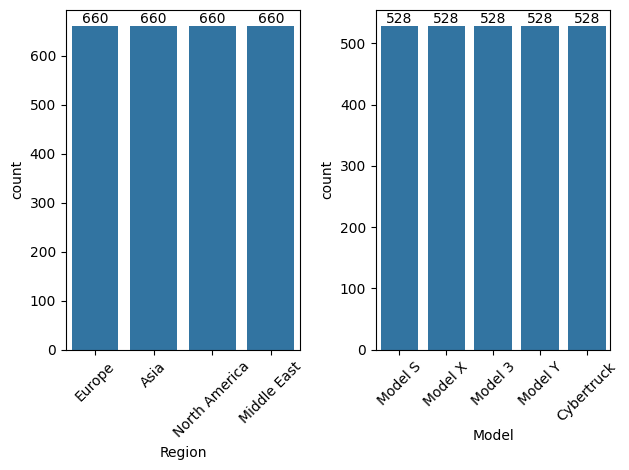

In [130]:
df_obj = data.select_dtypes(include='object')

for i, col in enumerate(df_obj.columns, 1):
    plt.subplot(1,2,i)
    ax = sns.countplot(x= df_obj[col])
    for c in ax.containers:
        plt.bar_label(c)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

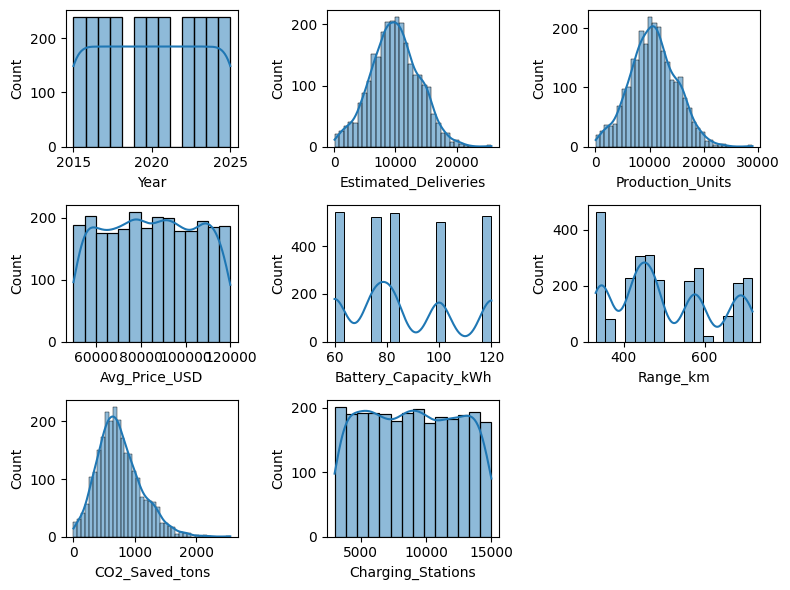

In [131]:
import math

df_num = data.select_dtypes(include='number')

n = len(df_num.columns)
cols = 3
rows = math.ceil(n/cols)
plt.figure(figsize=(8, 2*rows))

for i, col in enumerate(df_num.columns, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(data[col], kde=True)
plt.tight_layout()
plt.show()

### Correlation

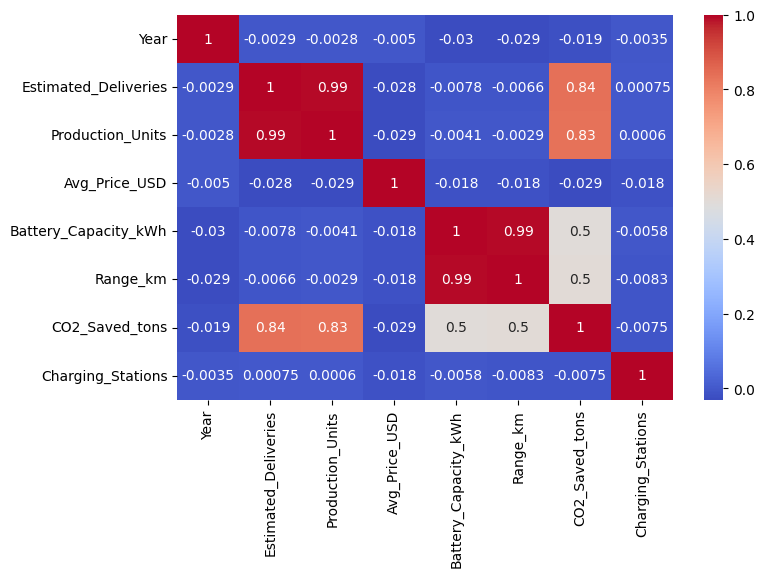

In [132]:
plt.figure(figsize=(8,5))
sns.heatmap(df_num.corr(), annot=True, cmap='coolwarm')
plt.show()

## Outliers

In [133]:
cols = data.select_dtypes(include='number').columns

q1 = data[cols].quantile(0.25)
q3 = data[cols].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = (data[cols] < lower) | (data[cols] > upper)

outliers.sum()

Year                     0
Estimated_Deliveries    12
Production_Units        12
Avg_Price_USD            0
Battery_Capacity_kWh     0
Range_km                 0
CO2_Saved_tons          45
Charging_Stations        0
dtype: int64

In [134]:
# # Remove Outliers
# data_clean = data[~outliers.any(axis=1)].copy()
# len(data), len(data_clean)


In [135]:
# # Re-Check
# outliers_clean = (data_clean[cols] < lower) | (data_clean[cols] > upper)
# outliers_clean.sum()


# Classical Assumption Test

In [136]:
import statsmodels.api as sm

# Linearity

In [137]:
X = df_num.drop(columns=['Estimated_Deliveries'])
y = df_num['Estimated_Deliveries']

X_const = sm.add_constant(X)
model_lin = sm.OLS(y, X_const).fit()

pred = model_lin.predict(X_const)
resid = y - pred


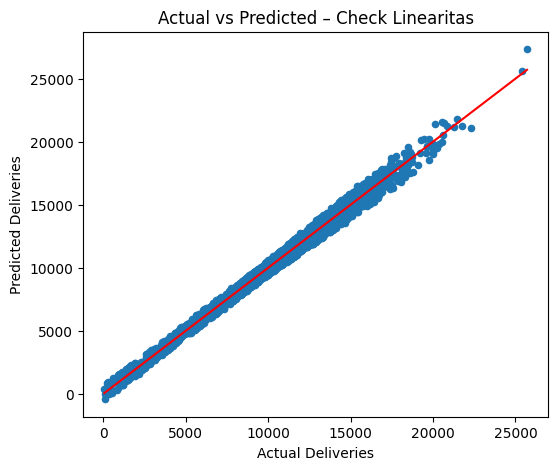

In [138]:
plt.figure(figsize=(6,5))
plt.scatter(y, pred, s=20)
plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted – Check Linearitas")
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')  # garis ideal
plt.show()


# Multicolinearity

In [139]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['Feature'] = X.columns
vif['VIF'] =  [variance_inflation_factor(X_const.values, i+1) for i in range(len(X.columns))]
vif

,Feature,VIF
0,Year,1.001204
1,Production_Units,14.778269
2,Avg_Price_USD,1.002017
3,Battery_Capacity_kWh,88.254957
4,Range_km,92.749534
5,CO2_Saved_tons,19.741408
6,Charging_Stations,1.001200


# Normality

In [140]:
from scipy.stats import shapiro

_, p_value = shapiro(resid)
print(f"{p_value:.5f}")
if p_value > 0.05:
    print('Normal Residual')
else:
    print('Not Normal')


0.00002
Not Normal


# Heteroskedastisity

In [141]:
abs_resid = np.abs(resid)

glejser_results = {}

for col in X.columns:
    X_g = sm.add_constant(X[col])
    model_g = sm.OLS(abs_resid, X_g).fit()
    glejser_results[col] = model_g.pvalues[col]

glejser_results

# p_value > 0.05 no hetero, else hetero detected

{'Year': 0.08165571451609883,
 'Production_Units': 1.3217113198661483e-80,
 'Avg_Price_USD': 0.382859012614959,
 'Battery_Capacity_kWh': 0.8061817716091724,
 'Range_km': 0.8608914877421926,
 'CO2_Saved_tons': 1.7529547990896263e-59,
 'Charging_Stations': 0.5214788446630979}

# AutoCorelation

In [142]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(resid)
print(dw)

if 1.5 < dw < 2.5:
    print("No autokol")
else:
    print("Autokol Detected")


1.998563860898689
No autokol


# Data Conclusion
- Several features show very high multicollinearity.
- Many variables have non-normal (skewed) distributions.
- Residuals also fail the normality test.
- Even though the residual pattern is linear, the other key assumptions are not satisfied.

=> Therefore, Linear Regression is not suitable because multicollinearity and non-normal residuals make the model unstable and statistically invalid.

=> The chosen model is XGBoost because it is robust to multicollinearity, does not require normality assumptions, and provides more stable and accurate predictions for this type of tabular data.

# Preprocessing

In [143]:
from sklearn.preprocessing import OneHotEncoder

ohe_reg = OneHotEncoder(sparse_output=False)
ohe_mod = OneHotEncoder(sparse_output= False)

enc_reg = ohe_reg.fit_transform(data[['Region']]).astype(int)
enc_mod = ohe_mod.fit_transform(data[['Model']]).astype(int)

enc_region = pd.DataFrame(enc_reg, columns= ohe_reg.get_feature_names_out(['Region']))
enc_model = pd.DataFrame(enc_mod, columns= ohe_mod.get_feature_names_out(['Model']))

data_enc = pd.concat([data, enc_region, enc_model], axis=1 )
data_enc

,Year,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Asia,Region_Europe,Region_Middle East,Region_North America,Model_Cybertruck,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
0,2023,Europe,Model S,17646,17922,92874.27,120,704,1863.42,12207,0,1,0,0,0,0,1,0,0
1,2015,Asia,Model X,3797,4164,62205.65,75,438,249.46,7640,1,0,0,0,0,0,0,1,0
2,2019,North America,Model X,8411,9189,117887.32,82,480,605.59,14071,0,0,0,1,0,0,0,1,0
3,2021,North America,Model 3,6555,7311,89294.91,120,712,700.07,9333,0,0,0,1,0,1,0,0,0
4,2016,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,8722,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,4273,0,0,1,0,0,0,0,0,1
2636,2019,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,9833,0,0,1,0,0,0,1,0,0
2637,2019,Asia,Model S,13291,14839,97139.38,100,580,1156.32,13709,1,0,0,0,0,0,1,0,0
2638,2020,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,6754,1,0,0,0,1,0,0,0,0


In [144]:
data_enc = data_enc.drop(columns=['Region', 'Model'])

# Modelling (XG Boost)

In [161]:
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

X = data_enc.drop(columns=['Estimated_Deliveries'])
y = data_enc['Estimated_Deliveries']

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

param_grid = {
    "n_estimators": [300, 500, 800],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.05, 0.01]
}

grid = GridSearchCV(
    estimator=XGBRegressor(),
    param_grid=param_grid,
    scoring="neg_mean_absolute_error",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best params:", grid.best_params_)
print("Best MAE:", abs(grid.best_score_))


Best params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 800}
Best MAE: 232.87042236328125


In [162]:
model_xgb = XGBRegressor(learning_rate = 0.05, max_depth = 5, n_estimators = 800)
model_xgb.fit(X_train, y_train)

y_pred = model_xgb.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)


MAE : 213.1566925048828
RMSE: 284.7688755815846
R²  : 0.9945597648620605


In [164]:
# CV
from sklearn.model_selection import cross_val_score, RepeatedKFold

cv = RepeatedKFold(n_splits=5, n_repeats= 3, random_state=42)
scores = cross_val_score(model_xgb, X_train, y_train, scoring='neg_mean_absolute_error', cv=cv, n_jobs=-1)

scor = np.absolute(scores)
print('MAE:',round(np.mean(scor), 2))
print('STD:',round(np.std(scor), 2))


MAE: 234.39
STD: 11.12


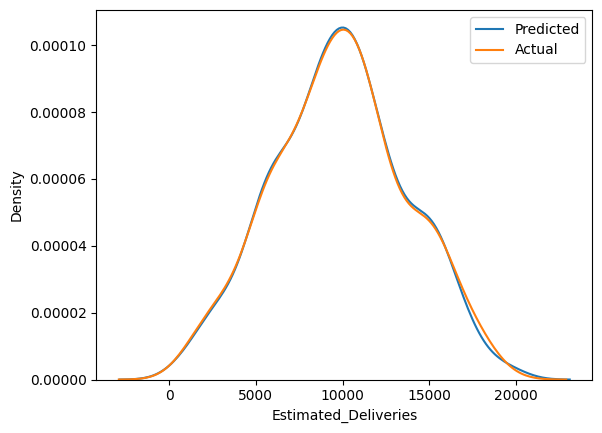

In [169]:
sns.kdeplot(y_pred, label = 'Predicted')
sns.kdeplot(y_test, label = 'Actual')
plt.legend()
plt.show()

# Testing New Data

In [208]:
data.iloc[[201]]

,Year,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
201,2018,North America,Model X,9743,10457,74615.49,100,595,869.56,9827


In [211]:
new_data = {
    'Year' : 2018,
    'Production_Units': 10457,
    'Avg_Price_USD': 74615.49,
    'Battery_Capacity_kWh': 100,
    'Range_km': 595,
    'CO2_Saved_tons': 869.56,
    'Charging_Stations': 9827,
    'Region': 'North America',
    'Model': 'Model X'
}

new_data = pd.DataFrame([new_data])
new_data

,Year,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region,Model
0,2018,10457,74615.49,100,595,869.56,9827,North America,Model X


In [212]:
enc_reg = ohe_reg.transform(new_data[['Region']]).astype(int)
enc_mod = ohe_mod.transform(new_data[['Model']]).astype(int)

enc_region = pd.DataFrame(enc_reg, columns= ohe_reg.get_feature_names_out())
enc_model = pd.DataFrame(enc_mod, columns= ohe_mod.get_feature_names_out())

new_data = pd.concat([new_data, enc_region, enc_model], axis=1 )
new_data = new_data.drop(columns=['Region', 'Model'])
new_data

,Year,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Asia,Region_Europe,Region_Middle East,Region_North America,Model_Cybertruck,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y
0,2018,10457,74615.49,100,595,869.56,9827,0,0,0,1,0,0,0,1,0


In [213]:
predicting = model_xgb.predict(new_data)
predicting

array([9713.5], dtype=float32)